In [1]:
from src.utils import get_path, find_closest_power_of_2
from src.QDDPM_torch_angel import QDDPM, WassDistance
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import torch

# Fake config file to use get_path()
# EDITABLE
config = {
    'dataset': {
        'dir': './data',
        'name': 'MNIST1',
    }
}
n_data, n_pixels, n_timesteps, n_ancilla_qubits, n_backward_layers  = 1000, 256, 40, 4, 6
_, n_qubits = find_closest_power_of_2(n_pixels, return_power=True)
diffusion_schedule = 'linear1'

Please first ``pip install -U qiskit`` to enable related functionality in translation module
Please first ``pip install -U cirq`` to enable related functionality in translation module
fail to load cloud provider module: tencent


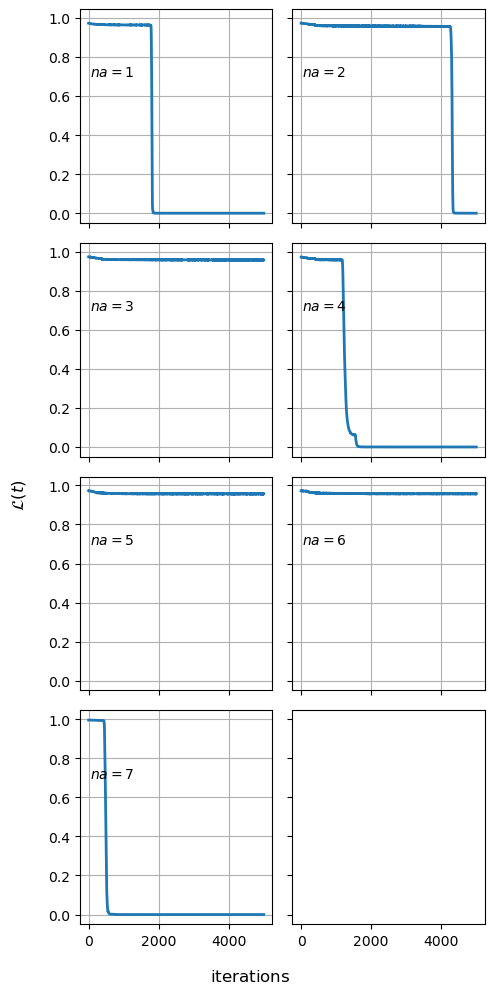

In [9]:
# Plot loss según el parametro que quieras
TIMESTEP = 40
values = range(1, 8)

size = 5
n_cols = 2
n_rows = 4
fig, axs = plt.subplots(n_rows, n_cols, figsize=(size, size+5), sharex=True, sharey=True)
for i, value in enumerate(values):
    n_ancilla_qubits = value

    dir, filename = get_path(config, type='modelsinglefinallosshist', n_data=n_data, n_pixels=n_pixels, n_qubits=n_qubits, n_ancilla_qubits=n_ancilla_qubits, n_timesteps=n_timesteps, n_backward_layers=n_backward_layers, t=TIMESTEP)
    loss = np.load(dir / filename)

    axs[i//n_cols, i%n_cols].plot(loss, lw=2)
    axs[i//n_cols, i%n_cols].text(x=30, y=0.7, s=r'$na=%d$'%(value), fontsize=10)
    axs[i//n_cols, i%n_cols].grid(True)

fig.supxlabel(r'$\rm iterations$')
fig.supylabel(r'$\mathcal{L}(t)$')
plt.tight_layout()

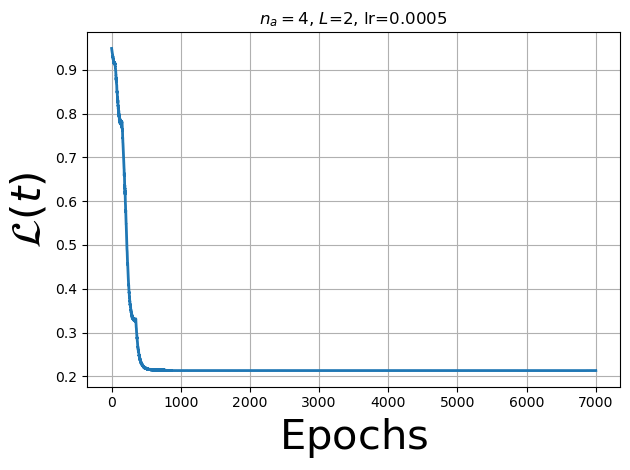

In [17]:
# Single plot
TIMESTEP = 12
n_backward_layers = 2
dir, filename = get_path(config, type='modelsinglefinallosshist', n_data=n_data, n_pixels=n_pixels, n_qubits=n_qubits, n_ancilla_qubits=n_ancilla_qubits, n_timesteps=n_timesteps, n_backward_layers=n_backward_layers, t=TIMESTEP)
loss = np.load(dir / filename)

plt.plot(loss, lw=2)
plt.grid(True)
plt.xlabel(r'$\rm Epochs$', fontsize=30)
plt.ylabel(r'$\mathcal{L}(t)$', fontsize=30)
plt.title(r'$n_a=%d$, $L$=%d, lr=0.0005'%(n_ancilla_qubits, n_backward_layers))
plt.tight_layout()

In [8]:
import numpy as np

def get_cosine_warm_restarts_array(epochs, T_0, T_mult, eta_max, eta_min):
    lrs = []
    T_cur = 0
    T_i = T_0
    
    for epoch in range(epochs):
        # Calculate eta_t using the formula
        # eta_t = eta_min + 0.5 * (eta_max - eta_min) * (1 + cos(pi * T_cur / T_i))
        lr = eta_min + 0.5 * (eta_max - eta_min) * (1 + np.cos(np.pi * T_cur / T_i))
        lrs.append(lr)
        
        T_cur += 1
        if T_cur >= T_i:
            T_cur = 0
            T_i *= T_mult
            
    return np.array(lrs)

# Parameters
total_epochs = 5000
T_0 = 50
T_mult = 2
eta_max = 0.005  # Example initial LR
eta_min = 0

lr_schedule = get_cosine_warm_restarts_array(total_epochs, T_0, T_mult, eta_max, eta_min)

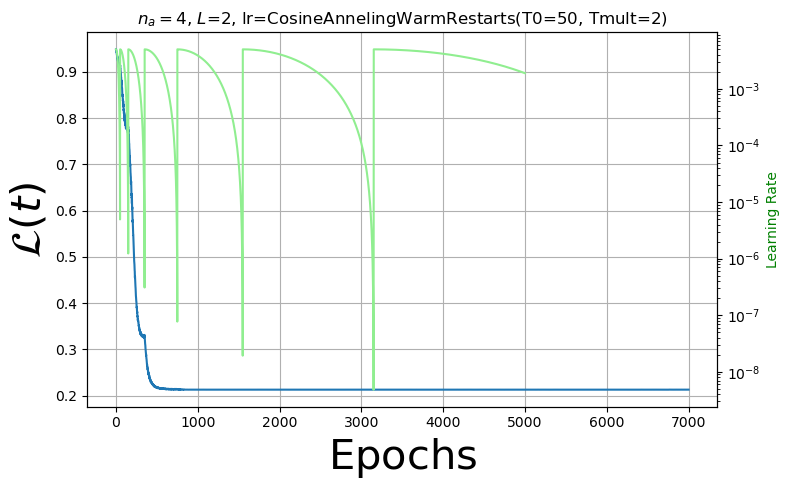

In [9]:
fig, ax1 = plt.subplots(figsize=(8, 5))

# Primary Y-Axis (Linear Scale)
ax1.plot(loss, label='Loss')
ax1.set_xlabel(r'$\rm Epochs$', fontsize=30)
ax1.set_ylabel(r'$\mathcal{L}(t)$', fontsize=30)

# Secondary Y-Axis (Log Scale)
ax2 = ax1.twinx()
ax2.plot(lr_schedule, color='lightgreen', label='Learning rate')
ax2.set_yscale('log')
ax2.set_ylabel('Learning Rate', color='green')

plt.title(r'$n_a=%d$, $L$=%d, lr=CosineAnnelingWarmRestarts(T0=50, Tmult=2)'%(n_ancilla_qubits, n_backward_layers))
fig.tight_layout()
ax1.grid(True)
plt.show()

In [23]:
print(n_qubits, n_ancilla_qubits, n_timesteps, n_backward_layers)

6 4 40 2


Denoised image at t=0.                     Input at t=1


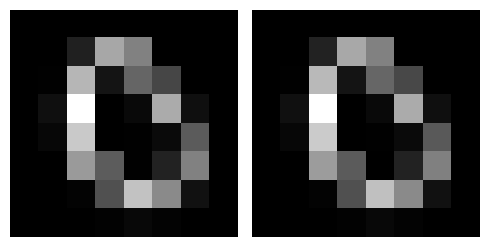

In [31]:
# Visualize the evolution of one image
TIMESTEP=12

# Compute the images across timesteps.
device = torch.device('cpu')
model = QDDPM(n_qubits, n_ancilla_qubits, n_timesteps, n_backward_layers, device=device).to(device)

n = 2 # select a sample
dir, filename = get_path(config, type='diffusedqstates', diffusion_schedule=diffusion_schedule, n_data=n_data, n_pixels=n_pixels, n_qubits=n_qubits,n_timesteps=n_timesteps)
states_diffused = np.load(dir / filename)
state_diffused = states_diffused[TIMESTEP, n] # timestep TIMESTEP, sample n
input_tplus1 = torch.zeros((1, 2**(n_qubits + n_ancilla_qubits)), device=device).cfloat()
input_tplus1[:, :2**n_qubits] = torch.from_numpy(state_diffused[np.newaxis, :])

# Load parameters
dir, filename = get_path(config, type='modelsingleparams', n_data=n_data, n_pixels=n_pixels, n_qubits=n_qubits, n_ancilla_qubits=n_ancilla_qubits, n_timesteps=n_timesteps, n_backward_layers=n_backward_layers, t=TIMESTEP)
params_t = torch.from_numpy(np.load(dir / filename)).to(device)

# Generate prediction
output = model.backwardOutput_t(input_tplus1, params_t)

# collect them in a single variable
states = torch.zeros((2, 1, 2**(n_qubits + n_ancilla_qubits)), device=device).cfloat()
states[1] = input_tplus1
states[0, :, :2**n_qubits] = output

# Visualize the evolution of one image
image_dim = int(np.sqrt(n_pixels))
fig, axs = plt.subplots(1,2, figsize=(5,5))
vmin, vmax = 0, 1
images = []
for i in range(2): 
    # Extract the probabilities and convert back to MNIST digits
    state = states[i,0]
    probs = (state*state.conj()).real
    probs = probs[:, np.newaxis][:n_pixels]
    image = probs.reshape(image_dim, image_dim)

    # Rescale the probabilities to the range [0,1]
    norm = 1 / image.max()
    image = image * norm

    images.append(image)

    axs[i].imshow(image, vmin=vmin, vmax=vmax, cmap='gray')
    axs[i].axis('off')

plt.tight_layout()
print("Denoised image at t=0.                     Input at t=1")

In [56]:
states_diffused[0,n].reshape(image_dim, image_dim).shape

(8, 8)

Original image at t=0


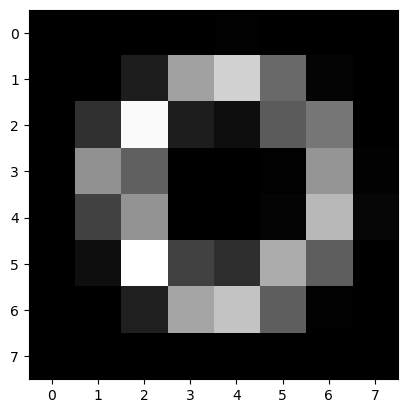

In [66]:
print("Original image at t=0")
state = states_diffused[0,n]
probs = (state*state.conj()).real
probs = probs[:, np.newaxis][:n_pixels]
image = probs.reshape(image_dim, image_dim)
norm = 1 / image.max()
image = image * norm
plt.imshow(image, vmin=vmin, vmax=vmax, cmap='gray')